In [1]:
# This is a test to check that the rhs is correctly calculated for a (non trivial) BH spacetime

# restart the kernel to clear past work
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [2]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
import time
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade code
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/source')
from initialdata.mytests import *                   # go here to change the test conditions

from matter.scalarmatter import *                   # the matter class to be used
from matter.nomatter import *                       # the matter class to be used

from backgrounds.sphericalbackground import *       # go here to look at the background hat metric and scalings
from core.grid import Grid                          # go here to see how the grid and derivatives are calculated
from core.spacing import *                          # go here to import spacing
from core.display import set_grid_on_ax             # to make plots look nice
from core.statevector import *                      # helps construct the state vector with the matter
from core.rhsevolution import *                     # go here to look at how the evolution works
from bssn.tensoralgebra import *                    # some useful tensor algebra functions
from bssn.constraintsdiagnostic import *                    # go here to change the  diagnostics

In [3]:
# Set up the chosen matter class
scalar_mu = 1.0
my_matter = ScalarMatter(scalar_mu)
my_state = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 80# outer edge of the grid (including ghosts)
min_dr = 1/64
max_dr = 1/8

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# my_spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
my_spacing = CubicSpacing(**params)

# Set up the grid and the background
grid = Grid(my_spacing, my_state)
r = grid.r
num_points = r.size
my_background = FlatSphericalBackground(r)

print("Grid params are", params)

Grid params are {'r_max': 80, 'extent': <SpacingExtent.HALF: 0>, 'a': 9.071147352221454, 'num_points': 1540}


In [4]:
# Test the rhs values, use eddington finkelstein which has non trivial Kij and shift
initial_state = get_test_state_bh(grid, my_background)

# unpackage the vector for readability

# Including Matter: 
[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(initial_state, grid.NUM_VARS)


# $D_i A_{jk}D^i A^{jk}$

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]

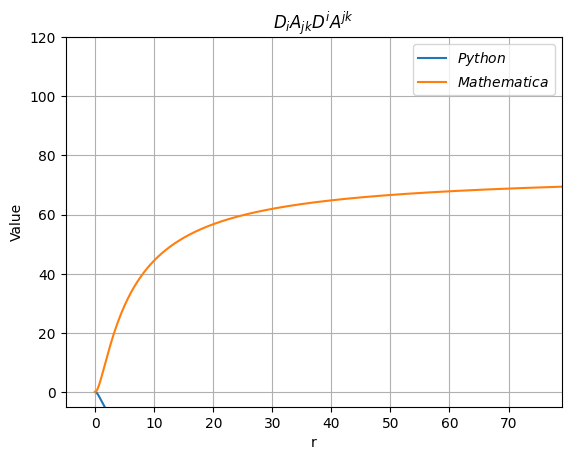

In [5]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0

def DiAjkDiAjk_Mathematica(r):
    num = 8*(189 + 2*r*(225 + 2*r*(103 + r*(43 + 7*r))))
    den = 3*(r**4)*((2 + r)**6)
    
    return num / den

contraction_Python = Contract[idx]

plt.plot(r, contraction_Python*r**6, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r)*r**6, label = '$Mathematica$', linestyle="-")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''

plt.title('$D_i A_{jk}D^i A^{jk}$')
plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(-5,79)
plt.ylim(-5,120)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# Diifferent contributions to the contraction

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]

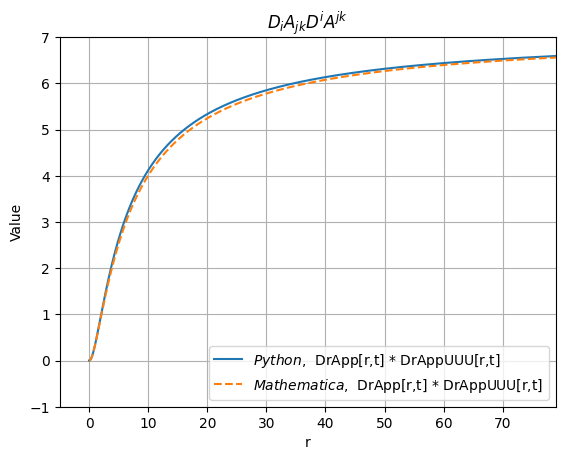

In [11]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0

# 1) DrArr[r] * DrArrUUU[r]
def term1(r):
    r = np.asarray(r)
    num = 16 * (9 + r*(11 + 4*r))**2
    den = 9 * r**4 * (2 + r)**6
    return num / den

# 2) DrAtt[r] * DrAttUUU[r]
def term2(r):
    r = np.asarray(r)
    num = 4 * (9 + r*(11 + 4*r))**2
    den = 9 * r**4 * (2 + r)**6
    return num / den

# 3) DrApp[r,t] * DrAppUUU[r,t]  (t cancels → no t-dependence)
def term3(r):
    r = np.asarray(r)
    num = 4 * (9 + r*(11 + 4*r))**2
    den = 9 * r**4 * (2 + r)**6
    return num / den

# 4) DtArt[r] * DtArtUUU[r]
def term4(r):
    r = np.asarray(r)
    num = 4 * (3 + 2*r)**2
    den = r**4 * (2 + r)**4
    return num / den

# 5) DpArp[r,t] * DpArpUUU[r,t]  (t cancels → same as term4)
def term5(r):
    r = np.asarray(r)
    num = 4 * (3 + 2*r)**2
    den = r**4 * (2 + r)**4
    return num / den



contraction1 = ContractDrArr[idx]
contraction2 = ContractDrAtt[idx]
contraction3 = ContractDrApp[idx]
contraction4 = ContractDtArt[idx]
contraction5 = ContractDpArp[idx]


#plt.plot(r, contraction1*r**6, label = '$Python$, DrArr[r] * DrArrUUU[r]', linestyle="-")
#plt.plot(r, contraction2*r**6, label = '$Python$, DrAtt[r] * DrAttUUU[r]', linestyle="-")
plt.plot(r, contraction3*r**6, label = '$Python$,  DrApp[r,t] * DrAppUUU[r,t]', linestyle="-")
#plt.plot(r, contraction4*r**6, label = '$Python$', linestyle="-")
#plt.plot(r, contraction5*r**6, label = '$Python$', linestyle="-")

#plt.plot(r, term1(r)*r**6, label = '$Mathematica$, DrArr[r] * DrArrUUU[r]', linestyle="--")
#plt.plot(r, term2(r)*r**6, label = '$Mathematica$, DrAtt[r] * DrAttUUU[r]', linestyle="--")
plt.plot(r, term3(r)*r**6, label = '$Mathematica$,  DrApp[r,t] * DrAppUUU[r,t]', linestyle="--")
#plt.plot(r, term4(r)*r**6, label = '$Mathematica$', linestyle="--")
#plt.plot(r, term5(r)*r**6, label = '$Mathematica$', linestyle="--")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''

plt.title('$D_i A_{jk}D^i A^{jk}$')
plt.xlabel('r')
plt.ylabel('Value')

'''
plt.xlim(-5,79)
plt.ylim(-5,120)
'''

plt.xlim(-5,79)
plt.ylim(-1,7)


plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# $D_i A_{jk}D^j A^{ik}$


  0%|                                                   | 0/1000 [00:08<?, ?‰/s]

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]

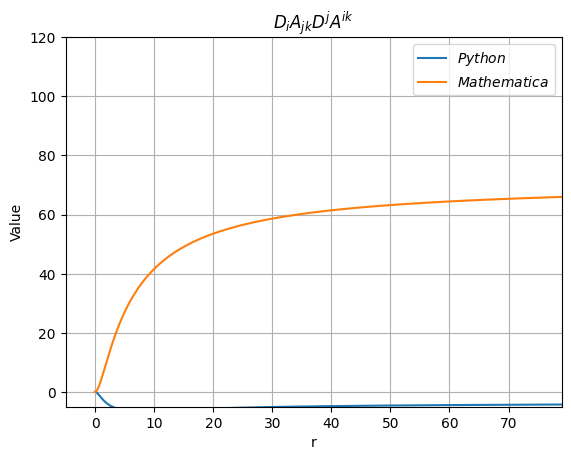

In [14]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0

def DiAjkDiAjk_Mathematica(r):

    num = 16 * (9 + r*(11 + 4*r)) * (27 + 2*r*(16 + 5*r))
    den = 9 * (r**4) * ((2 + r)**6)
    return num / den 

contraction_Python = Contract2[idx]

plt.plot(r, contraction_Python*r**6, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r)*r**6, label = '$Mathematica$', linestyle="-")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''

plt.title('$D_i A_{jk}D^j A^{ik}$')
plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(-5,79)
plt.ylim(-5,120)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# $D_i A_{jk}D^j A^{ik}$ Different Contributions to the contractions


  0%|                                                   | 0/1000 [00:01<?, ?‰/s]

  0%|                                                   | 0/1000 [00:01<?, ?‰/s]

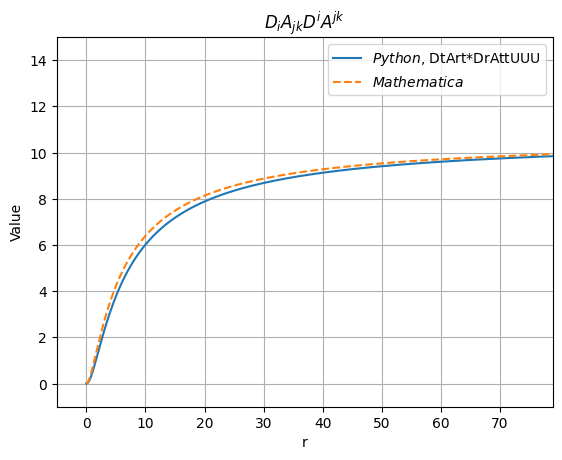

In [8]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0

def term(r):
    r = np.asarray(r)
    num = 4 * (3 + 2*r) * (9 + r*(11 + 4*r))
    den = 3 * (r**4) * ((2 + r)**5)
    return num / den  




contraction5 = Contract5_[idx]
contraction6 = Contract6_[idx]
contraction7 = Contract7_[idx]
contraction8 = Contract8_[idx]


plt.plot(r, contraction5*r**6, label = '$Python$, DtArt*DrAttUUU', linestyle="-")
#plt.plot(r, contraction6*r**6, label = '$Python$, DrAtt*DtArtUUU', linestyle="-")
#plt.plot(r, contraction7*r**6, label = '$Python$, DpArp*DrAppUUU', linestyle="-")
#plt.plot(r, contraction8*r**6, label = '$Python$, DrApp*DpArpUUU', linestyle="-")


plt.plot(r, term(r)*r**6, label = '$Mathematica$', linestyle="--")


'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''

plt.title('$D_i A_{jk}D^i A^{jk}$')
plt.xlabel('r')
plt.ylabel('Value')

'''
plt.xlim(-5,79)
plt.ylim(-5,120)
'''

plt.xlim(-5,79)
plt.ylim(-1,15)


plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# Checking $\partial_i \bar{A}_{jk}$ with Python

## s_times_d1_a 

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]/var/folders/82/hfbwh4bs1l33b4r39m2rnhv00000gn/T/ipykernel_67398/3276775175.py:11: RuntimeWarning: invalid value encountered in power
  return -2 * ((2 + r)/r)**(1/6) * (21 + r*(29 + 12*r)) / (9 * (2 + r)**3)


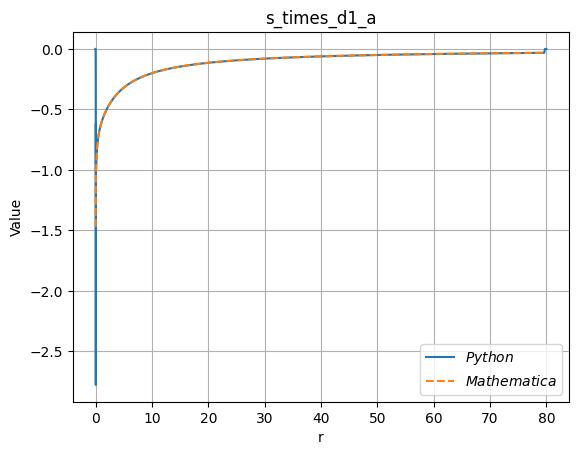

In [9]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0

def term(r):
    r = np.asarray(r, dtype=float)
    return -2 * ((2 + r)/r)**(1/6) * (21 + r*(29 + 12*r)) / (9 * (2 + r)**3)

'''
def term(r):
    return - (2*r*(21 + r*(29 + 12*r))) / (9*(2 + r)**2 * ((2 + r)/r)**(5/6))

'''    
De = Deriv[idx]

plt.plot(r, De, label = '$Python$', linestyle="-")
plt.plot(r, term(r), label = '$Mathematica$', linestyle="--")


plt.title('s_times_d1_a')
plt.xlabel('r')
plt.ylabel('Value')

'''
plt.xlim(-5,79)
plt.ylim(-5,120)
'''



plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

## a_times_d1_s


  0%|                                                   | 0/1000 [00:01<?, ?‰/s]

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]/var/folders/82/hfbwh4bs1l33b4r39m2rnhv00000gn/T/ipykernel_67398/1561569758.py:11: RuntimeWarning: invalid value encountered in power
  return 4*(3 + 2*r) / (3 * r**2 * ((2 + r)/r)**(11/6))


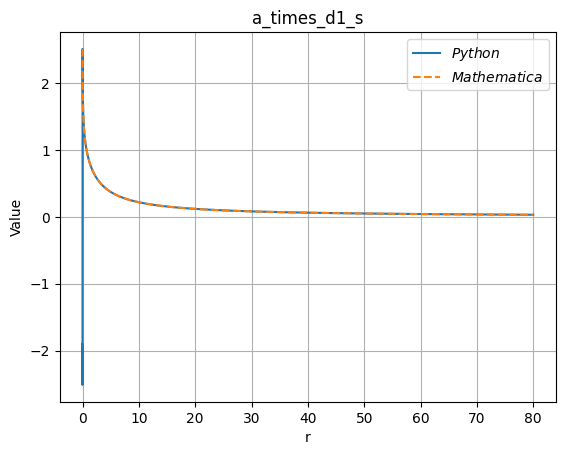

In [10]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0

def term(r):
    r = np.asarray(r, dtype=float)
    return 4*(3 + 2*r) / (3 * r**2 * ((2 + r)/r)**(11/6)) 

    
De = Deriv2[idx]

plt.plot(r, De, label = '$Python$', linestyle="-")
plt.plot(r, term(r), label = '$Mathematica$', linestyle="--")


plt.title('a_times_d1_s')
plt.xlabel('r')
plt.ylabel('Value')

'''
plt.xlim(-5,79)
plt.ylim(-5,120)
'''



plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# 

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]/var/folders/82/hfbwh4bs1l33b4r39m2rnhv00000gn/T/ipykernel_64938/2110147765.py:11: RuntimeWarning: invalid value encountered in power
  return (6 + 4*r) / (3 * r * ((2 + r)/r)**(11/6))


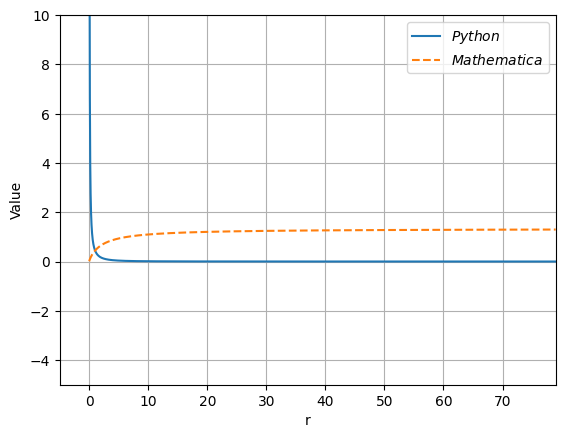

In [11]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0

def term(r):
    r = np.asarray(r, dtype=float)
    return (6 + 4*r) / (3 * r * ((2 + r)/r)**(11/6))

    
baAtt = barAtt[idx]
baApp = barApp[idx]


plt.plot(r, baAtt, label = '$Python$', linestyle="-")
plt.plot(r, term(r), label = '$Mathematica$', linestyle="--")



plt.xlabel('r')
plt.ylabel('Value')


plt.xlim(-5,79)
plt.ylim(-5,10)





plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# $D_i D^i \alpha$ (works but with Katy her definition from bssnrhs)

In [11]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0
# *r**6

def Mathematica(r):
    return 4 * np.sqrt((2 + r) / r) / (2 + r)**4


Python = D2lapser[idx]


plt.plot(r, Python*r**4, label = '$Python$', linestyle="-")
plt.plot(r, Mathematica(r)*r**4, label = '$Mathematica$', linestyle="--")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''


plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(0,78)
plt.ylim(0,4)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]

IndexError: list index out of range

# $A_{ij}A^{ij}$ (at least something that fucking works)

In [ ]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])

[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0
# *r**6

def Mathematica(r):
    return 8 * (3 + 2*r)**2 / (3 * r**3 * (2 + r)**3)


Python = Asqua[idx]


plt.plot(r, Python*r**6, label = '$Python$', linestyle="-")
plt.plot(r, Mathematica(r)*r**6, label = '$Mathematica$', linestyle="--")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''


plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(0,10)
plt.ylim(-40,600)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# $\partial_iK \partial^i K$ (it shouldn't matter with what metric you raise but it does ?)

In [ ]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])
[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0
# *r**6

def Mathematica(r):
    return 4 * ((2 + r) / r) ** (1/3) * (9 + 2 * r * (5 + r)) ** 2 / (r**4 * (2 + r)**6)


Python = KKK[idx]


plt.plot(r, Python*r**6, label = '$Python$', linestyle="-")
plt.plot(r, Mathematica(r)*r**6, label = '$Mathematica$', linestyle="--")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''


plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(0,10)
plt.ylim(-100,100)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# $D_iD_j \alpha  \;\gamma^{ia}\gamma^{jb}  D_aD_b \alpha$ (finish this on paper first...)

In [ ]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])
[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0
# *r**6

def Mathematica(r):
    return (8 + 8*r + 6*r**2) / (r * (2 + r)**7)
    
Python = dkldkllapse[idx]


plt.plot(r, Python*r**6, label = '$Python$', linestyle="-")
plt.plot(r, Mathematica(r)*r**6, label = '$Mathematica$', linestyle="--")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''


plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(0,70)
plt.ylim(0,6)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# $\bar{A}_{kj}\bar{A}^{j}_{\;l}$

# $N_i N^i$ (Is just zero analytically)

# $M_{ij}^{TF} M^{TF,ij}$

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]/var/folders/82/hfbwh4bs1l33b4r39m2rnhv00000gn/T/ipykernel_34441/534103691.py:12: RuntimeWarning: invalid value encountered in power
  18 * (-x**(1/3) + x**(2/3))
/var/folders/82/hfbwh4bs1l33b4r39m2rnhv00000gn/T/ipykernel_34441/534103691.py:13: RuntimeWarning: invalid value encountered in power
  + r * (66 - 18*x**(1/3) + 24*x**(2/3)
/var/folders/82/hfbwh4bs1l33b4r39m2rnhv00000gn/T/ipykernel_34441/534103691.py:14: RuntimeWarning: invalid value encountered in power
  + r * (104 - 4*x**(1/3) + 8*x**(2/3) + 9*r*(6 + r)))


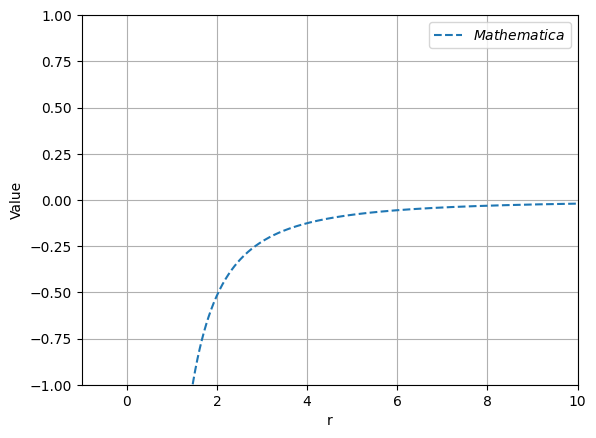

In [11]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])
[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0
# *r**6

def Mathematica(r):
    x = (2 + r) / r  # assume r > 0
    return -(2 / (9 * r**3 * (2 + r)**3)) * (
        18 * (-x**(1/3) + x**(2/3))
        + r * (66 - 18*x**(1/3) + 24*x**(2/3)
        + r * (104 - 4*x**(1/3) + 8*x**(2/3) + 9*r*(6 + r)))
    )
    
Python = TFM[idx]


#plt.plot(r, Python*r**6, label = '$Python$', linestyle="-")
plt.plot(r, Mathematica(r), label = '$Mathematica$', linestyle="--")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''


plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(-1,10)
plt.ylim(-1,1)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# Ricci Scalar $R_{ij}\gamma^{ij} = R$ (Matches)


  0%|                                                   | 0/1000 [00:00<?, ?‰/s]

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]

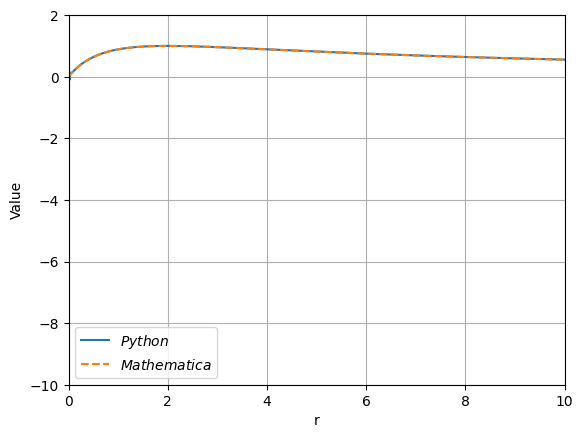

In [12]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])
[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0
# *r**6

def Mathematica(r):
    return 8 / (r**2 * (2 + r)**2)


Python = RicciScalar[idx]
#Python2 = RicciScalar2[idx]


plt.plot(r, Python*r**3, label = '$Python$', linestyle="-")
#plt.plot(r, Python2*r**3, label = '$Python$', linestyle="--")
plt.plot(r, Mathematica(r)*r**3, label = '$Mathematica$', linestyle="--")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''


plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(0,10)
plt.ylim(-10,2)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)

# Line 1 Mathematica vs Python (Line 1 is analytically just zero!)

# Line 2 Mathematica vs Python 

  0%|                                                   | 0/1000 [00:00<?, ?‰/s]

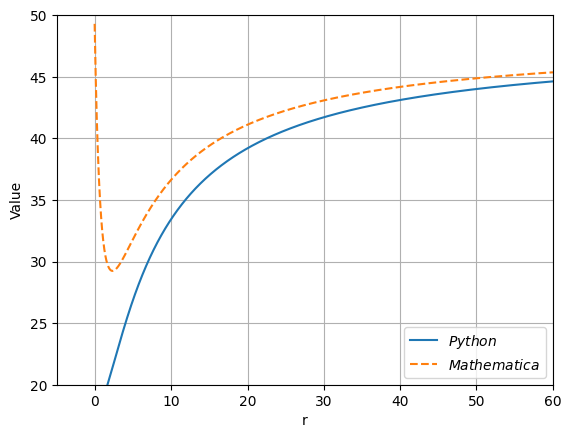

In [13]:
# calculate the rhs values and plot them
progress_bar = tqdm(total=1000, unit="‰")
solution = get_rhs(0.0, initial_state, grid, my_background, my_matter, progress_bar, [0, 1])
[phi,hrr,htt,hpp,K,arr,att,app,lambdar,shiftr,br,lapse, u, v] = np.array_split(solution, grid.NUM_VARS)

idx = 0
# *r**6

def Mathematica(r):
    return 16 * (72 + r * (60 + r * (22 + 9*r))) / (3 * r**6 * (2 + r)**3)



Python = line2_[idx]
Python2 = line3_[idx]



plt.plot(r, (Python+Python2)*r**6, label = '$Python$', linestyle="-")
plt.plot(r, Mathematica(r)*r**6, label = '$Mathematica$', linestyle="--")

'''
plt.plot(r, contraction_Python, label = '$Python$', linestyle="-")
plt.plot(r, DiAjkDiAjk_Mathematica(r), label = '$Mathematica$', linestyle="-")
'''


plt.xlabel('r')
plt.ylabel('Value')

plt.xlim(-5,60)
plt.ylim(20,50)

'''
plt.xlim(0.5,3)
plt.ylim(-0.01,2)
'''

plt.legend(loc='best')
plt.grid()
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)